In [11]:
import torch
import torchvision.models as models
import torch.nn as nn
from utils import get_loaders, train, plot_training_history, set_seed
from pathlib import Path

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print("Using device:", device)

Using device: cuda


In [ ]:
DATA_DIR = Path("/content/cinic_data/data")


TRAIN_DIR = DATA_DIR / "train"
VALID_DIR = DATA_DIR / "valid"
TEST_DIR = DATA_DIR / "test"

In [2]:
DATA_DIR = Path("/content/cinic_data/data")


TRAIN_DIR = DATA_DIR / "train"
VALID_DIR = DATA_DIR / "valid"
TEST_DIR = DATA_DIR / "test"


In [12]:
BATCH_SIZE = 256
train_loader, valid_loader, test_loader = get_loaders(train_dir=TRAIN_DIR, valid_dir=VALID_DIR,
                                                      test_dir=TEST_DIR, image_size=32, batch_size=BATCH_SIZE)

#### Training ResNet model from scratch

In [13]:
resnet_model = models.resnet18(weights=None)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 10)
resnet_model = resnet_model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet_model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.3)

In [14]:
set_seed(42)
resnet_training_history = train(resnet_model, train_loader, valid_loader, criterion, optimizer, scheduler,
                        device=device, num_epochs=20, checkpoint_name='resnet')

Epoch 1/20 | Train Loss: 1.5412 | Valid Loss: 1.3607 | Valid Acc: 0.5062
Epoch 2/20 | Train Loss: 1.2446 | Valid Loss: 1.2799 | Valid Acc: 0.5359
Epoch 3/20 | Train Loss: 1.1023 | Valid Loss: 1.1490 | Valid Acc: 0.5871
Epoch 4/20 | Train Loss: 1.0021 | Valid Loss: 1.0922 | Valid Acc: 0.6097
Epoch 5/20 | Train Loss: 0.9075 | Valid Loss: 1.1375 | Valid Acc: 0.5962
Epoch 6/20 | Train Loss: 0.8109 | Valid Loss: 1.1285 | Valid Acc: 0.6136
Epoch 7/20 | Train Loss: 0.7161 | Valid Loss: 1.1080 | Valid Acc: 0.6206
Epoch 8/20 | Train Loss: 0.6198 | Valid Loss: 1.2294 | Valid Acc: 0.6134
Epoch 9/20 | Train Loss: 0.3139 | Valid Loss: 1.3604 | Valid Acc: 0.6345
Epoch 10/20 | Train Loss: 0.1746 | Valid Loss: 1.6682 | Valid Acc: 0.6283
Epoch 11/20 | Train Loss: 0.1133 | Valid Loss: 1.9138 | Valid Acc: 0.6228
Epoch 12/20 | Train Loss: 0.0840 | Valid Loss: 2.2104 | Valid Acc: 0.6223
Epoch 13/20 | Train Loss: 0.0266 | Valid Loss: 2.6421 | Valid Acc: 0.6283
Epoch 14/20 | Train Loss: 0.0084 | Valid Loss: 

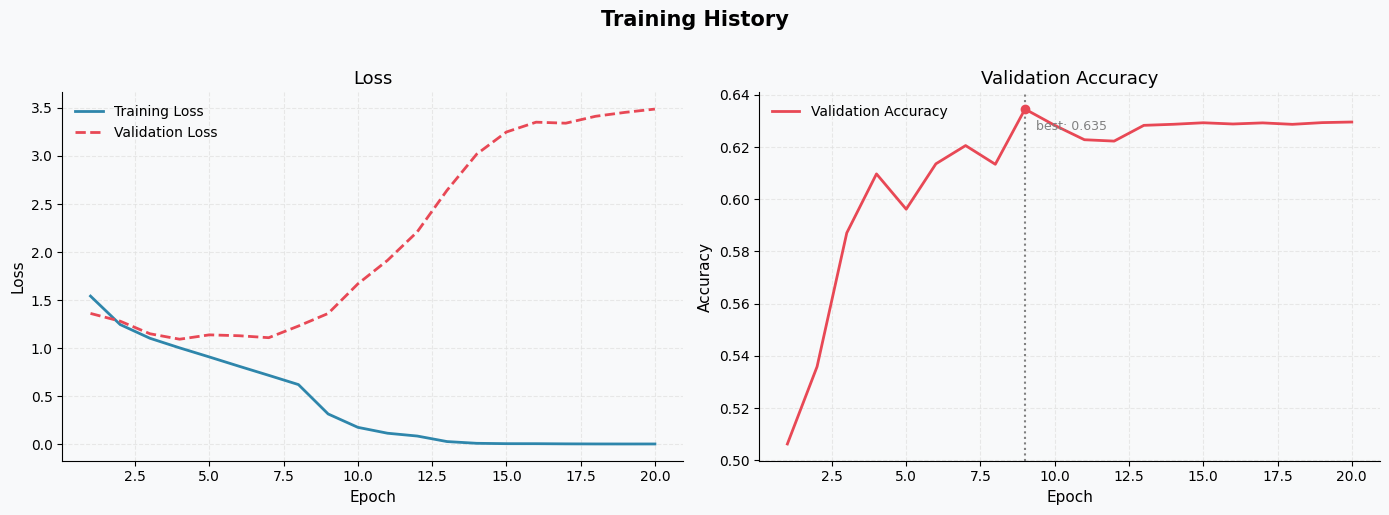

In [16]:
plot_training_history(resnet_training_history)